In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from datetime import timedelta
from math import sqrt
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from sklearn.preprocessing import MinMaxScaler

In [ ]:
file_path = 'Station1-cleaned-merged-data.csv'
data = pd.read_csv(file_path)
full_data = data.copy()
#Set to Datetime
data['Date'] = pd.to_datetime(data['Date'])

#Normalize Data

Create a list of numeric columns and then calculate the mean and standard deviation of entire dataset, normalize the data by taking each column, subtracting the mean and divide by the standard deviation.

In [ ]:
#Add columns to be normalized
numeric_columns = ['Ppt']

# Calculate the mean and standard deviation of the dataset
data_mean = data[numeric_columns].mean()
data_std = data[numeric_columns].std()


# Normalize the dataset
data_normalized = (data[numeric_columns] - data_mean) / data_std

# Melt the DataFrame
data_melted = data_normalized.melt(var_name='Column', value_name='Normalized')


<ipython-input-5-82e6c49814ef>:4: UserWarning: FixedFormatter should only be used together with FixedLocator
  _ = ax.set_xticklabels(data_normalized.keys(), rotation=90)


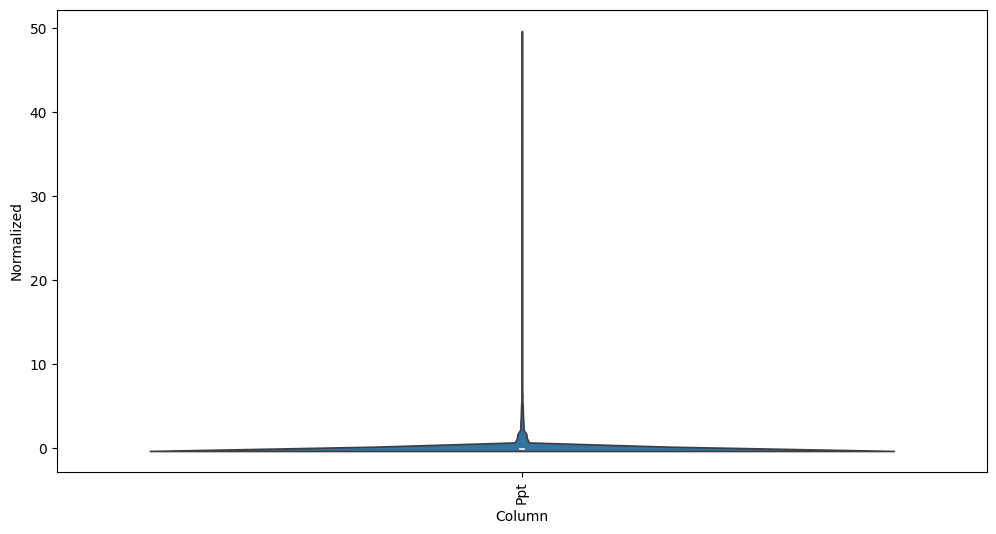

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=data_melted)

_ = ax.set_xticklabels(data_normalized.keys(), rotation=90)
plt.show()

#Feature Engineering

Create different windows for sum of past precipitation values to help engineer the prediction percentages of rain. Chosen windows are 1hr, 2hr,5hr, 10hr, and 24hr. After creating windows, shift 1 level back so they are not including the current rain therefore are past window sums. Then use sums to equal predicted rain given x amount of hours.

In [ ]:
na_counts = data.isna().sum()
print("NA counts per column:")
print(na_counts)

NA counts per column:
Date         0
SWC_5        0
SWC_10       0
SWC_20       0
SWC_50       0
T_5          0
T_10         0
T_20         0
T_50         0
Tair         0
RH           0
Srad         0
Ppt          0
Wx           0
Wy           0
Day sin      0
Day cos      0
Year sin     0
Year cos     0
Latitude     0
Longitude    0
dtype: int64


In [ ]:
days = 1
data['Sum_Rain_1h'] = data['Ppt'].rolling(window=1, min_periods=1).sum()
data['Sum_Rain_2h'] = data['Ppt'].rolling(window=2, min_periods=1).sum()
data['Sum_Rain_5h'] = data['Ppt'].rolling(window=5, min_periods=1).sum()
data['Sum_Rain_10h'] = data['Ppt'].rolling(window=10, min_periods=1).sum()
data['Sum_Rain_24h'] = data['Ppt'].rolling(window=24 * days, min_periods=1).sum()

In [ ]:
#Shift data by 1 to not include current rain in window
data['Sum_Rain_1h_Shifted'] = data['Sum_Rain_1h'].shift(1)
data['Sum_Rain_2h_Shifted'] = data['Sum_Rain_2h'].shift(1)
data['Sum_Rain_5h_Shifted'] = data['Sum_Rain_5h'].shift(1)
data['Sum_Rain_10h_Shifted'] = data['Sum_Rain_10h'].shift(1)
data['Sum_Rain_24h_Shifted'] = data['Sum_Rain_24h'].shift(1)

In [ ]:
#Actual rain for prediction
data['Actual_Rain_Next_Hour'] = data['Ppt'].shift(-1)
#Set predicted rain to the sum of shifted rain
data['Predicted_Rain_Next_Hour_1h'] = data['Sum_Rain_1h_Shifted']
data['Predicted_Rain_Next_Hour_2h'] = data['Sum_Rain_2h_Shifted']
data['Predicted_Rain_Next_Hour_5h'] = data['Sum_Rain_5h_Shifted']
data['Predicted_Rain_Next_Hour_10h'] = data['Sum_Rain_10h_Shifted']
data['Predicted_Rain_Next_Hour_24h'] = data['Sum_Rain_24h_Shifted']

In [ ]:
#Cutoff first 48hours of data
cutoff_date = data['Date'].min() + pd.Timedelta(days=2)
data = data[data['Date'] >= cutoff_date]

#Scaling and rain calculation methods

columns_to_scale: Created to scale values to range 0-1

calculate_rain_chance: Used to calculate the actual rain chance of a given hour of precipitation in mm. Creates different ranges coresponding to percentage of rain going off of different ranges from research online.

calculate_rain_chance_withsum: The prediction rain chance method, given the different sums of past rainfall for 1hr, 2hhr,5hr,10hr,24hr creates different scenarios and adds or subtracts rain percentages value given the values of different sums.

In [ ]:
columns_to_scale = [
    'Ppt',
    'Predicted_Rain_Next_Hour_1h',
    'Predicted_Rain_Next_Hour_2h',
    'Predicted_Rain_Next_Hour_5h',
    'Predicted_Rain_Next_Hour_10h',
    'Predicted_Rain_Next_Hour_24h'
]

# Apply Min-Max scaling to each column to a number between 0-1
for col in columns_to_scale:
    min_value = data[col].min()
    max_value = data[col].max()
    data[col + '_Scaled'] = (data[col] - min_value) / (max_value - min_value)

In [ ]:
def calculate_rain_chance(ppt):
    # Expanded thresholds for finer granularity
    if ppt == 0:
        return 0  # 0% chance if no rain
    elif 0 < ppt <= 0.1:
        return 4  # 4% chance for very minimal rain
    elif 0.1 < ppt <= 0.2:
        return 5  # 5% chance
    elif 0.2 < ppt <= 0.3:
        return 6  # 6% chance
    elif 0.3 < ppt <= 0.5:
        return 10  # 10% chance for light rain
    elif 0.5 < ppt <= 0.7:
        return 20  # 20% chance
    elif 0.7 < ppt <= 1.0:
        return 30  # 30% chance for moderate rain
    elif 1.0 < ppt <= 1.5:
        return 40  # 40% chance
    elif 1.5 < ppt <= 2.0:
        return 50  # 50% chance for heavy rain
    elif 2.0 < ppt <= 2.5:
        return 60  # 60% chance
    elif 2.5 < ppt <= 3.0:
        return 70  # 70% chance for very heavy rain
    elif 3.0 < ppt <= 3.5:
        return 80  # 80% chance
    elif 3.5 < ppt <= 4.0:
        return 90  # 90% chance
    else:
        return 100  # 100% chance for extreme rain conditions


In [ ]:
def calculate_rain_chance_withsum(sum_1h, sum_2h, sum_5h, sum_10h, sum_24h):
    rain_chance = 0  # Initialize the rain chance percentage

    # Base increase for any rain in the last hour
    if sum_1h > 0 and sum_1h< 0.5:
      rain_chance+= 4
    elif sum_1h > 0:
        rain_chance += sum_1h * 10  # Increase proportional to amount in the last hour

    # Additional adjustments based on rain over 2 hours and 5 hours
    if sum_2h > sum_1h:
        rain_chance += (sum_2h - sum_1h) * 10  # Weighted increase for additional rain in the last 2 hours
    if sum_5h > sum_2h:
        rain_chance += (sum_5h - sum_2h) * 5  # Further increase for rain over the last 5 hours

    # Consider recent dry period with rain further back
    if sum_10h > sum_5h and sum_1h == 0:
        rain_chance -= 5  # Decrease if recent dry period but rain 10 hours ago
    if sum_24h > sum_10h and sum_1h == 0 and sum_5h <= sum_2h:
        rain_chance -= 10  # Additional decrease for dry recent hours but rain 24 hours ago

    # Special conditions for very recent versus older rainfall
    if sum_1h == 0 and sum_10h > 0:
        rain_chance += 5  # Slight increase for rain 10 hours ago with recent dryness
    if sum_24h > 0 and sum_10h == 0:
        rain_chance += 2  # Minimal increase for rain 24 hours ago without more recent rain

    if sum_1h > 1 and sum_2h > 2:
        rain_chance += 10  # Bonus increase for significant recent rain
    elif sum_5h > 3 and sum_10h > 5:
        rain_chance += 5  # Moderate bonus for extended rain period

    # Ensure the chance does not fall below 0% or exceed 100%
    rain_chance = max(0, min(100, rain_chance))

    return rain_chance


In [ ]:
def calculate_combined_rain_chance(sum_1h, sum_3h, sum_5h, sum_10h, sum_24h):
    # Immediate, 1-hour rain chance based on recent conditions
    rain_chance_1hr = calculate_rain_chance_withsum(sum_1h, sum_3h, sum_5h, sum_10h, sum_24h)

    # Initialize baseline chances for longer-term predictions
    rain_chance_2days = 5  # Base chance for rain in the next 2 days
    rain_chance_5days = 2  # Base chance for rain in the next 5 days
    rain_chance_7days = 1  # Base chance for rain in the next 7 days

    # Adjust longer-term forecasts based on total rainfall in the past 24 hours
    if sum_24h > 10:
        rain_chance_2days += 25; rain_chance_5days += 20; rain_chance_7days += 15
    elif sum_24h > 5:
        rain_chance_2days += 15; rain_chance_5days += 10; rain_chance_7days += 5
    elif sum_24h > 3:
        rain_chance_2days += 10; rain_chance_5days += 5; rain_chance_7days += 2
    elif sum_24h > 1:
        rain_chance_2days += 5; rain_chance_5days += 2; rain_chance_7days += 1

    # Ensure chances do not exceed 100%
    rain_chance_1hr = min(100, rain_chance_1hr)
    rain_chance_2days = min(100, rain_chance_2days)
    rain_chance_5days = min(100, rain_chance_5days)
    rain_chance_7days = min(100, rain_chance_7days)

    return {
        'Predict_1hr_Percentage': rain_chance_1hr,
        'Predict_2days_Percentage': rain_chance_2days,
        'Predict_5days_Percentage': rain_chance_5days,
        'Predict_7days_Percentage': rain_chance_7days
    }

In [ ]:
predictions = data.apply(lambda row: pd.Series(calculate_combined_rain_chance(row['Sum_Rain_1h'], row['Sum_Rain_2h'], row['Sum_Rain_5h'], row['Sum_Rain_10h'], row['Sum_Rain_24h'])), axis=1)
data = pd.concat([data, predictions], axis=1)

In [ ]:
data['Actual_Rain_Chance'] = data['Ppt'].apply(calculate_rain_chance)

In [ ]:
data['Rain_Chance_Percentage'] = data.apply(lambda row: calculate_rain_chance_withsum(
    row['Sum_Rain_1h'],
    row['Sum_Rain_2h'],
    row['Sum_Rain_5h'],
    row['Sum_Rain_10h'],
    row['Sum_Rain_24h']), axis=1)

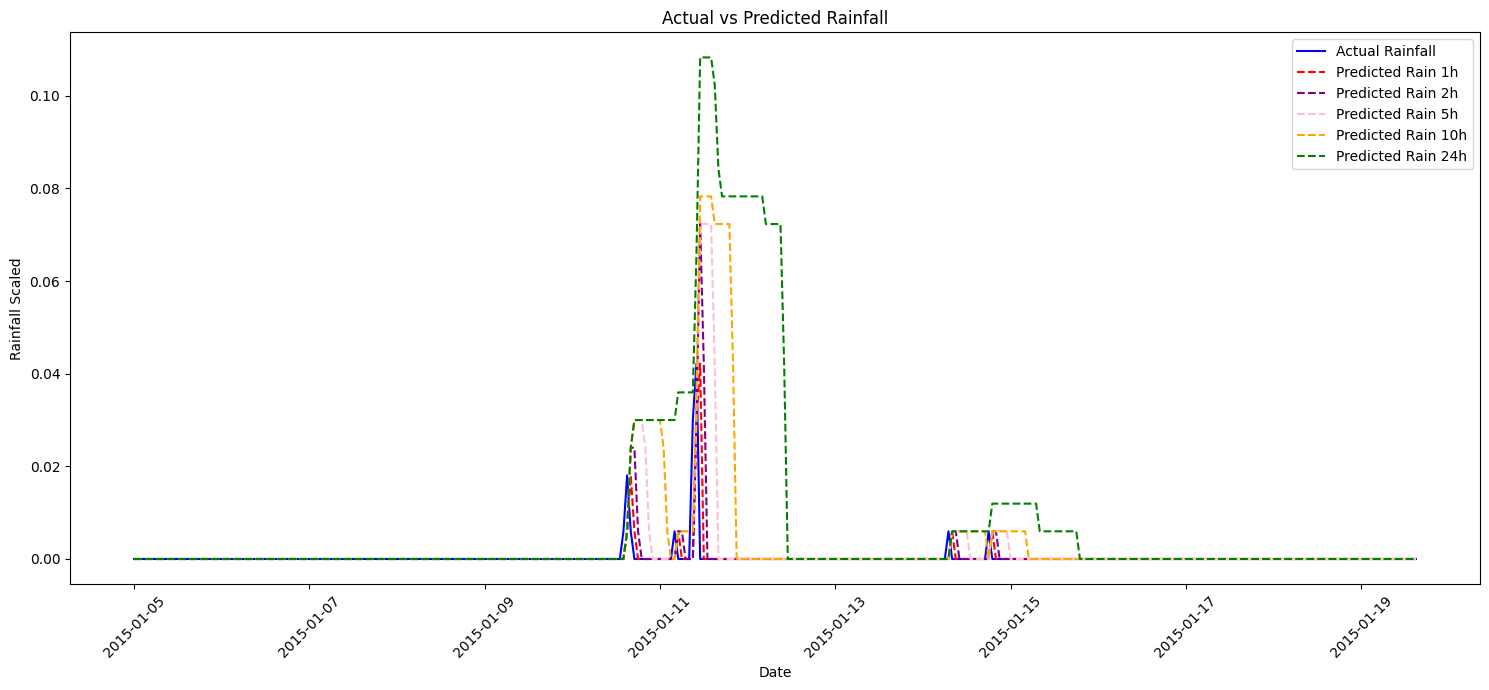

In [ ]:
data_chunk = data.iloc[48:400]

# Plot all predicted values for a chunk of the dataset
plt.figure(figsize=(15, 7))
plt.plot(data_chunk['Date'], data_chunk['Ppt'], label='Actual Rainfall', color='blue')
plt.plot(data_chunk['Date'], data_chunk['Predicted_Rain_Next_Hour_1h'], label='Predicted Rain 1h', linestyle='--', color='red')
plt.plot(data_chunk['Date'], data_chunk['Predicted_Rain_Next_Hour_2h'], label='Predicted Rain 2h', linestyle='--', color='purple')
plt.plot(data_chunk['Date'], data_chunk['Predicted_Rain_Next_Hour_5h'], label='Predicted Rain 5h', linestyle='--', color='pink')
plt.plot(data_chunk['Date'], data_chunk['Predicted_Rain_Next_Hour_10h'], label='Predicted Rain 10h', linestyle='--', color='orange')
plt.plot(data_chunk['Date'], data_chunk['Predicted_Rain_Next_Hour_24h'], label='Predicted Rain 24h', linestyle='--', color='green')

plt.title('Actual vs Predicted Rainfall')
plt.xlabel('Date')
plt.ylabel('Rainfall Scaled')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

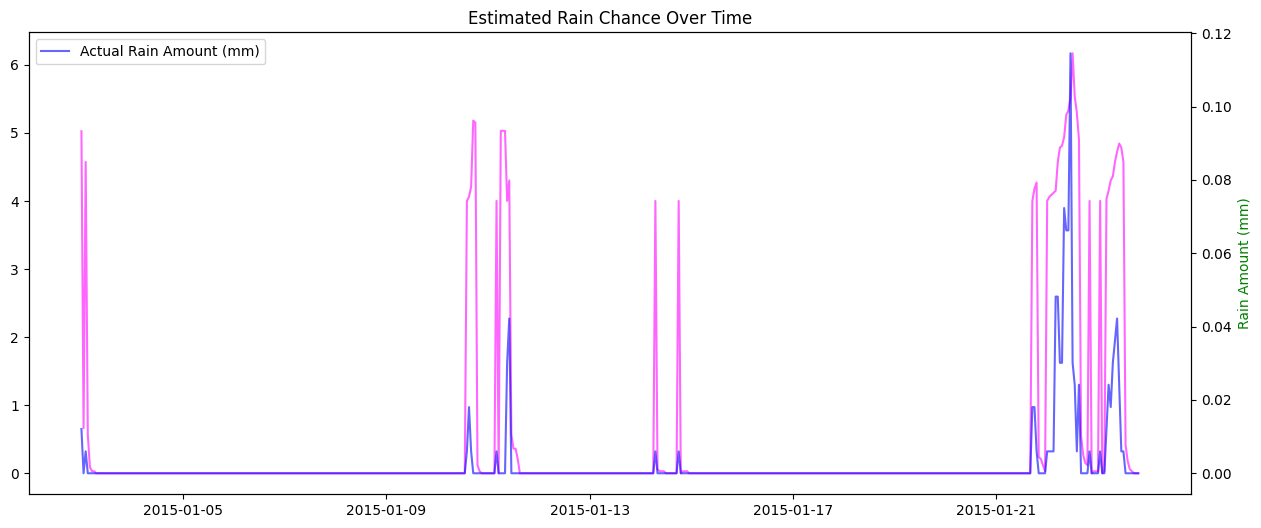

In [ ]:
data_chunk = data.iloc[0:500]
plt.figure(figsize=(15, 6))
plt.plot(data_chunk['Date'], data_chunk['Rain_Chance_Percentage'], label='Estimated Rain Chance', color='magenta', alpha=0.6)
plt.title('Estimated Rain Chance Over Time')

# Create a secondary y-axis for the actual rain amount
ax2 = plt.gca().twinx()
ax2.plot(data_chunk['Date'], data_chunk['Ppt'], label='Actual Rain Amount (mm)', color='blue', alpha=0.6)

plt.xlabel('Date')
plt.ylabel('Rain Chance Percentage')
ax2.set_ylabel('Rain Amount (mm)', color='green')
plt.legend()
plt.show()


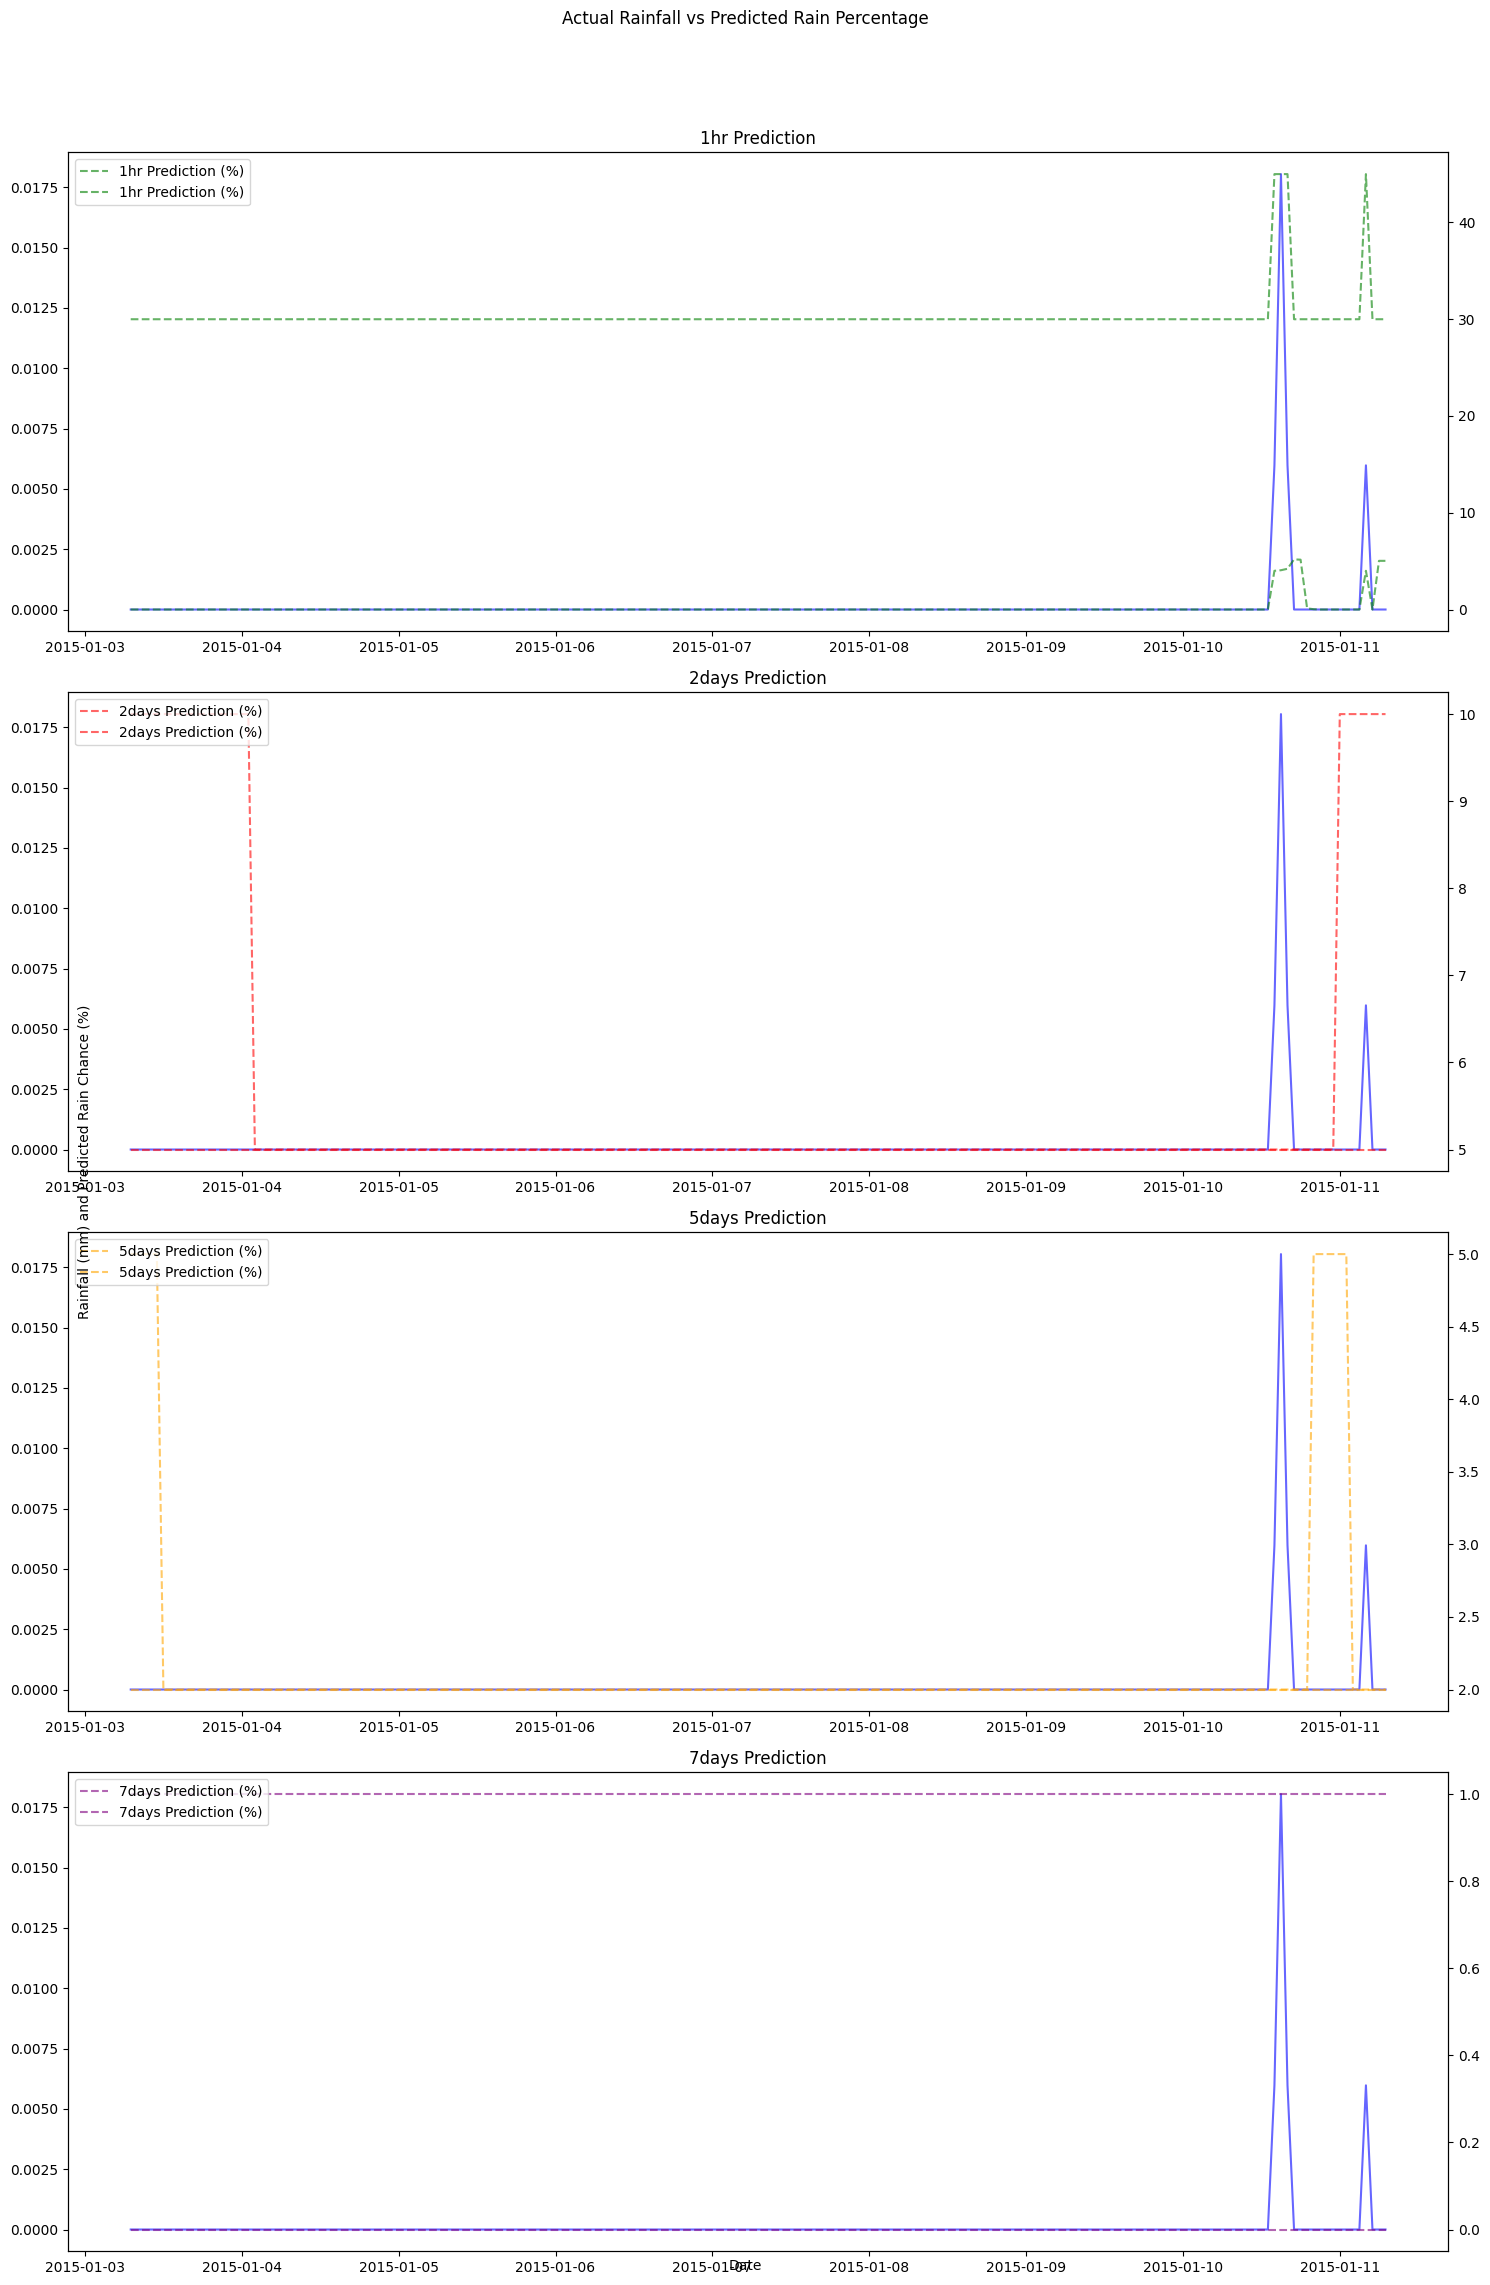

In [ ]:


data_chunk = data.iloc[7:200]
fig, axs = plt.subplots(4, 1, figsize=(15, 24))

# Setting common labels and title
fig.text(0.5, 0.04, 'Date', ha='center', va='center')
fig.text(0.06, 0.5, 'Rainfall (mm) and Predicted Rain Chance (%)', ha='center', va='center', rotation='vertical')
fig.suptitle('Actual Rainfall vs Predicted Rain Percentage')

# Actual Rainfall vs 1hr Prediction
axs[0].plot(data_chunk['Date'], data_chunk['Ppt'], label='Actual Rainfall (mm)', color='blue', alpha=0.6)
ax1 = axs[0].twinx()
ax1.plot(data_chunk['Date'], data_chunk['Predict_1hr_Percentage'], label='1hr Prediction (%)', color='green', alpha=0.6, linestyle='--')
axs[0].set_title('1hr Prediction')

# Actual Rainfall vs 2days Prediction
axs[1].plot(data_chunk['Date'], data_chunk['Ppt'], label='Actual Rainfall (mm)', color='blue', alpha=0.6)
ax2 = axs[1].twinx()
ax2.plot(data_chunk['Date'], data_chunk['Predict_2days_Percentage'], label='2days Prediction (%)', color='red', alpha=0.6, linestyle='--')
axs[1].set_title('2days Prediction')

# Actual Rainfall vs 5days Prediction
axs[2].plot(data_chunk['Date'], data_chunk['Ppt'], label='Actual Rainfall (mm)', color='blue', alpha=0.6)
ax3 = axs[2].twinx()
ax3.plot(data_chunk['Date'], data_chunk['Predict_5days_Percentage'], label='5days Prediction (%)', color='orange', alpha=0.6, linestyle='--')
axs[2].set_title('5days Prediction')

# Actual Rainfall vs 7days Prediction
axs[3].plot(data_chunk['Date'], data_chunk['Ppt'], label='Actual Rainfall (mm)', color='blue', alpha=0.6)
ax4 = axs[3].twinx()
ax4.plot(data_chunk['Date'], data_chunk['Predict_7days_Percentage'], label='7days Prediction (%)', color='purple', alpha=0.6, linestyle='--')
axs[3].set_title('7days Prediction')


ax1.legend(loc='upper left')
ax2.legend(loc='upper left')
ax3.legend(loc='upper left')
ax4.legend(loc='upper left')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
print(data['Predict_5days_Percentage'])


48       2.0
49       2.0
50       2.0
51       2.0
52       2.0
        ... 
57581    2.0
57582    2.0
57583    2.0
57584    2.0
57585    2.0
Name: Predict_5days_Percentage, Length: 57538, dtype: float64


#Prediction Error

Create a method to caclulate the MSE for the different predicated rain values and then also calcualte the MAE and MSE for the predicted percentages from using the actual eprcentage as a base for comparison

In [ ]:
#prediction error MSE from predicted rain values to actual rain sums
data['MSE_1h'] = ((data['Predicted_Rain_Next_Hour_1h'] - data['Actual_Rain_Next_Hour']) ** 2)
data['MSE_2h'] = ((data['Predicted_Rain_Next_Hour_2h'] - data['Actual_Rain_Next_Hour']) ** 2)
data['MSE_5h'] = ((data['Predicted_Rain_Next_Hour_5h'] - data['Actual_Rain_Next_Hour']) ** 2)
data['MSE_10h'] = ((data['Predicted_Rain_Next_Hour_10h'] - data['Actual_Rain_Next_Hour']) ** 2)
data['MSE_24h'] = ((data['Predicted_Rain_Next_Hour_24h'] - data['Actual_Rain_Next_Hour']) ** 2)

<ipython-input-115-6e7994bd2ffa>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['MSE_1h'] = ((data['Predicted_Rain_Next_Hour_1h'] - data['Actual_Rain_Next_Hour']) ** 2)
<ipython-input-115-6e7994bd2ffa>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['MSE_2h'] = ((data['Predicted_Rain_Next_Hour_2h'] - data['Actual_Rain_Next_Hour']) ** 2)
<ipython-input-115-6e7994bd2ffa>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

In [ ]:
# Define the columns to calculate MSE
predicted_columns = [
    'Predicted_Rain_Next_Hour_1h',
    'Predicted_Rain_Next_Hour_2h',
    'Predicted_Rain_Next_Hour_5h',
    'Predicted_Rain_Next_Hour_10h',
    'Predicted_Rain_Next_Hour_24h',
]

# Calculate MSE for each prediction column
mse_values = {}
for col in predicted_columns:
    mse = ((data[col] - data['Actual_Rain_Next_Hour']) ** 2).mean()
    mse_values[col] = mse

# Printing MSE values
for col, mse in mse_values.items():
    print(f"MSE for {col}: {mse}")

MSE for Predicted_Rain_Next_Hour_1h: 0.0006983223225197312
MSE for Predicted_Rain_Next_Hour_2h: 0.0013089873103752836
MSE for Predicted_Rain_Next_Hour_5h: 0.003835925681062888
MSE for Predicted_Rain_Next_Hour_10h: 0.009060514677763691
MSE for Predicted_Rain_Next_Hour_24h: 0.02759059978595504


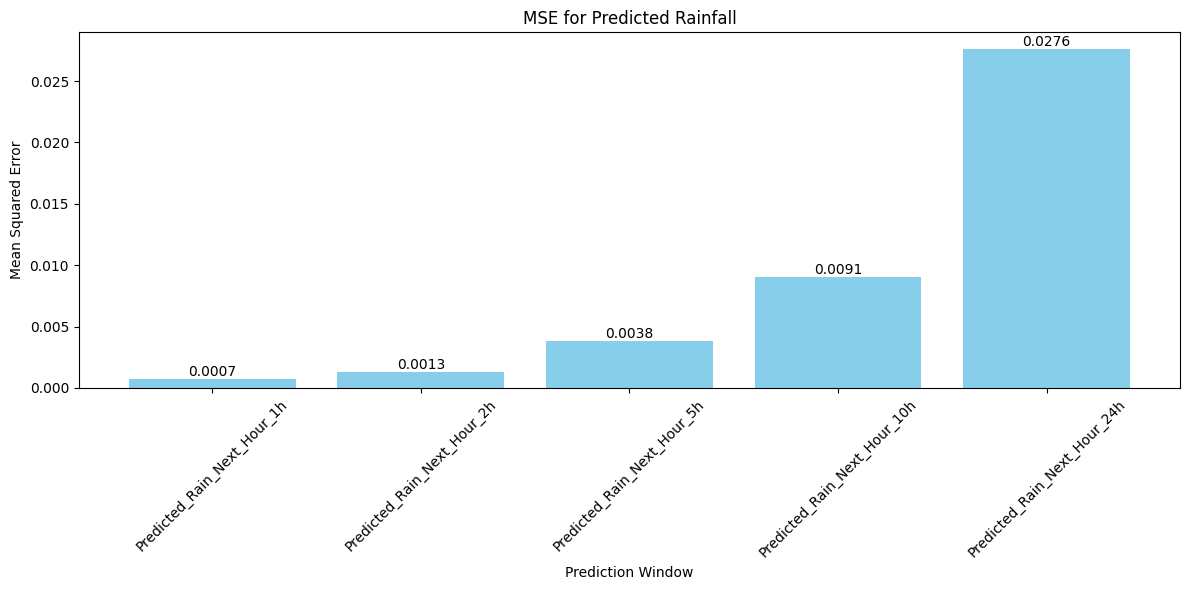

In [ ]:

# Converting the MSE values dictionary to lists for plotting
columns = list(mse_values.keys())
mse_scores = list(mse_values.values())

plt.figure(figsize=(12, 6))
plt.bar(columns, mse_scores, color='skyblue')
plt.xlabel('Prediction Window')
plt.ylabel('Mean Squared Error')
plt.title('MSE for Predicted Rainfall')
plt.xticks(rotation=45)
plt.tight_layout()

#  MSE values on top of each bar for clarity
for i, mse in enumerate(mse_scores):
    plt.text(i, mse, f"{mse:.4f}", ha='center', va='bottom')

plt.show()

In [ ]:
# Calculate MAE and MSE
mae = mean_absolute_error(data['Actual_Rain_Chance'], data['Rain_Chance_Percentage'])
mse = mean_squared_error(data['Actual_Rain_Chance'], data['Rain_Chance_Percentage'])

# Calculate MAE as a percentage of the average actual rain
average_actual_rain = data['Actual_Rain_Chance'].mean()
mae_percentage = (mae / average_actual_rain) * 100

#Print values
print('mae', mae)
print('mse', mse)

mae 0.08164658676523182
mse 0.4354917423460345


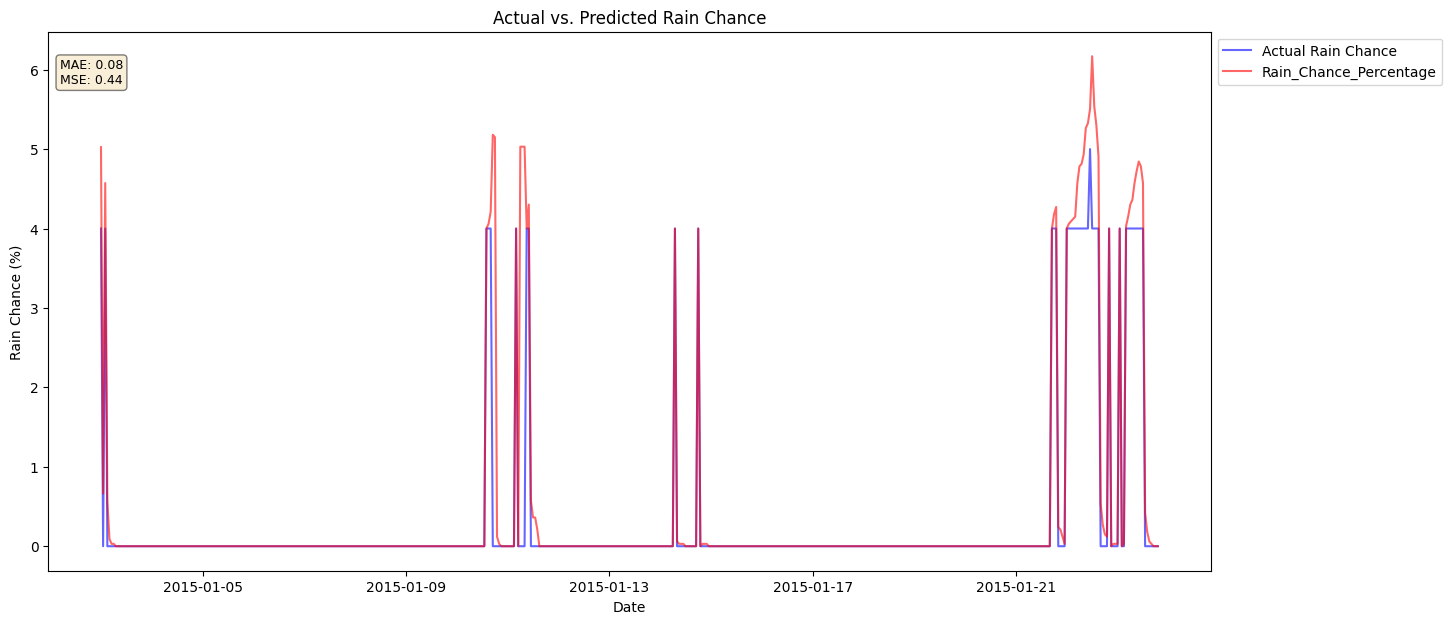

In [ ]:
data_chunk = data.iloc[:500]

plt.figure(figsize=(15, 7))

# Plotting Actual and Predicted Rain
plt.plot(data_chunk['Date'], data_chunk['Actual_Rain_Chance'], label='Actual Rain Chance', color='blue', alpha=0.6)
plt.plot(data_chunk['Date'], data_chunk['Rain_Chance_Percentage'], label='Rain_Chance_Percentage', color='red', alpha=0.6)

# MAE and MSE
plt.text(0.01, 0.95, f'MAE: {mae:.2f}\nMSE: {mse:.2f}', transform=plt.gca().transAxes, fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Setting the labels, title, and legend
plt.xlabel('Date')
plt.ylabel('Rain Chance (%)')
plt.title('Actual vs. Predicted Rain Chance')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.show()

#Export to CSV

In [ ]:
print(data.columns)

Index(['Date', 'SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20',
       'T_50', 'Tair', 'RH', 'Srad', 'Ppt', 'Wx', 'Wy', 'Day sin', 'Day cos',
       'Year sin', 'Year cos', 'Latitude', 'Longitude', 'Sum_Rain_1h',
       'Sum_Rain_2h', 'Sum_Rain_5h', 'Sum_Rain_10h', 'Sum_Rain_24h',
       'Sum_Rain_1h_Shifted', 'Sum_Rain_2h_Shifted', 'Sum_Rain_5h_Shifted',
       'Sum_Rain_10h_Shifted', 'Sum_Rain_24h_Shifted', 'Actual_Rain_Next_Hour',
       'Predicted_Rain_Next_Hour_1h', 'Predicted_Rain_Next_Hour_2h',
       'Predicted_Rain_Next_Hour_5h', 'Predicted_Rain_Next_Hour_10h',
       'Predicted_Rain_Next_Hour_24h', 'Predict_1hr_Percentage',
       'Predict_2days_Percentage', 'Predict_5days_Percentage',
       'Predict_7days_Percentage', 'Actual_Rain_Chance',
       'Rain_Chance_Percentage'],
      dtype='object')


In [ ]:
columns_to_drop = [
    'Actual_Rain_Next_Hour',
    'Actual_Rain_Chance',
    'Sum_Rain_1h_Shifted',
    'Sum_Rain_2h_Shifted',
    'Sum_Rain_5h_Shifted',
    'Sum_Rain_10h_Shifted',
    'Sum_Rain_24h_Shifted',
    'Predicted_Rain_Next_Hour_2h',
    'Predicted_Rain_Next_Hour_5h',
    'Predicted_Rain_Next_Hour_10h',
    'Predicted_Rain_Next_Hour_24h',
    'Rain_Chance_Percentage'
]

# Drop the specified columns from the DataFrame
data_cleaned = data.drop(columns=columns_to_drop, errors='ignore')

In [ ]:
print(data_cleaned.columns)

Index(['Date', 'SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20',
       'T_50', 'Tair', 'RH', 'Srad', 'Ppt', 'Wx', 'Wy', 'Day sin', 'Day cos',
       'Year sin', 'Year cos', 'Latitude', 'Longitude', 'Sum_Rain_1h',
       'Sum_Rain_2h', 'Sum_Rain_5h', 'Sum_Rain_10h', 'Sum_Rain_24h',
       'Predicted_Rain_Next_Hour_1h', 'Predict_1hr_Percentage',
       'Predict_2days_Percentage', 'Predict_5days_Percentage',
       'Predict_7days_Percentage'],
      dtype='object')


In [ ]:
data_cleaned.to_csv('/content/cleaned_data.csv', index=False)

In [ ]:
from google.colab import files
files.download('/content/cleaned_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>